# MScFE 622 Stochastic Modeling - Group Work Project #2
## Step 1 - Data Preparation and Exploration

This notebook is the canonical technical analysis artifact. Step 1 constructs the maximum common daily sample for TLT, GLD, SPY, and VIX, reports the required ETF log returns and VIX first differences, and visualizes both series groups. Numerical results below are produced from the committed canonical Step 1 dataset; no values are estimated manually.

### Data source and financial interpretation

The project pipeline downloads daily Yahoo Finance **Adjusted Close** series for TLT, GLD, and SPY and the Yahoo Finance VIX series (`^VIX`), then retains dates on which all four prices are present. The VIX Index is designed as a forward-looking, approximately 30-day measure of expected S&P 500 volatility inferred from SPX option quotations (Cboe Global Markets). Whaley likewise describes the VIX as an option-market volatility benchmark and explains its financial interpretation (Whaley 98-105).

<!-- citekey: cboe2019vixfaq -->
<!-- citekey: whaley2009vix -->

**Source note.** Market observations: Yahoo Finance, downloaded by the project loader required by the assignment. VIX interpretation: Cboe Global Markets and Whaley (2009). Calculations and figures: project team.

In [1]:
import re
from pathlib import Path
from tempfile import TemporaryDirectory

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from vix_regime_allocation.plots import plot_etf_log_returns, plot_vix_change
from vix_regime_allocation.transform import OUTPUT_COLUMNS

repo_root = Path.cwd()
if not (repo_root / "data/processed/step1_data.csv").is_file():
    repo_root = repo_root.parent

data_path = repo_root / "data/processed/step1_data.csv"
references_path = repo_root / "reports/references.bib"
data = pd.read_csv(data_path, parse_dates=["Date"], index_col="Date")
data.index.name = "Date"

assert tuple(data.columns) == OUTPUT_COLUMNS
assert isinstance(data.index, pd.DatetimeIndex)
assert data.index.is_monotonic_increasing
assert not data.index.has_duplicates
assert not data.isna().any().any()
assert np.isfinite(data.to_numpy(dtype=float)).all()
assert (data[["TLT", "GLD", "SPY", "VIX"]] > 0.0).all().all()

data.head()

,TLT,GLD,SPY,VIX,TLT_log_return,GLD_log_return,SPY_log_return,VIX_change
Date,,,,,,,,
2004-11-19,43.302605,44.779999,78.858780,13.50,-0.008012,0.008973,-0.011178,0.520000
2004-11-22,43.528297,44.950001,79.234833,12.97,0.005198,0.003789,0.004757,-0.530000
2004-11-23,43.582287,44.750000,79.355743,12.67,0.001240,-0.004459,0.001525,-0.300000
2004-11-24,43.582287,45.049999,79.543793,12.72,0.000000,0.006682,0.002367,0.050000
2004-11-26,43.297714,45.290001,79.483330,12.78,-0.006551,0.005313,-0.000760,0.059999


In [2]:
sample_summary = pd.DataFrame(
    {
        "value": [
            data.index.min().date().isoformat(),
            data.index.max().date().isoformat(),
            len(data),
            int(data.isna().sum().sum()),
        ]
    },
    index=["start_date", "end_date", "observations", "missing_values"],
)
sample_summary

,value
start_date,2004-11-19
end_date,2026-08-17
observations,5465
missing_values,0


### ETF daily log returns

For ETF $i$ on trading row $t$, Step 1 uses the daily log return

$$
r_{i,t}=\ln\left(\frac{P_{i,t}}{P_{i,t-1}}\right),
$$

where $P_{i,t}$ is the adjusted close for ETF $i$ at row $t$. Missing common dates are removed **before** this lag is formed; there is no filling or interpolation. The first row is then removed because it has no preceding common-sample observation.

### Daily change in VIX

**Greek letter used below:** $\Delta$ - **delta**, pronounced *DEL-tuh*, meaning a finite change or difference.

The Step 1 VIX observation is the first difference

$$
\Delta VIX_t = VIX_t - VIX_{t-1}.
$$

This is a level change, not a percentage return. It measures how the option-implied volatility index changed between consecutive rows of the common sample.

In [3]:
analysis_columns = [
    "TLT_log_return",
    "GLD_log_return",
    "SPY_log_return",
    "VIX_change",
]
descriptive_statistics = data[analysis_columns].describe().T
descriptive_statistics

,count,mean,std,min,25%,50%,75%,max
TLT_log_return,5465.0,0.000114,0.009156,-0.069011,-0.005299,0.000432,0.005458,0.072503
GLD_log_return,5465.0,0.000405,0.011492,-0.108412,-0.005154,0.000590,0.006348,0.106974
SPY_log_return,5465.0,0.000416,0.011904,-0.115887,-0.003935,0.000718,0.005781,0.135577
VIX_change,5465.0,0.000404,1.901620,-18.710003,-0.720000,-0.099999,0.570000,24.860001


In [4]:
vix_extreme_date = data["VIX_change"].abs().idxmax()
vix_extreme_change = float(data.loc[vix_extreme_date, "VIX_change"])
etf_std = data[["TLT_log_return", "GLD_log_return", "SPY_log_return"]].std(ddof=1)
highest_std_series = str(etf_std.idxmax())
highest_std_value = float(etf_std.loc[highest_std_series])

display(
    Markdown(
        "**Computed Step 1 observations.** "
        f"The common sample contains **{len(data)}** rows from "
        f"**{data.index.min().date().isoformat()}** through "
        f"**{data.index.max().date().isoformat()}**. "
        f"The largest absolute daily VIX change occurs on "
        f"**{vix_extreme_date.date().isoformat()}** and equals "
        f"**{repr(vix_extreme_change)}** VIX points. "
        f"Among the three ETF log-return series, **{highest_std_series}** has the "
        f"largest sample daily standard deviation, **{repr(highest_std_value)}**, "
        "using `ddof=1`."
    )
)

**Computed Step 1 observations.** The common sample contains **5465** rows from **2004-11-19** through **2026-08-17**. The largest absolute daily VIX change occurs on **2020-03-16** and equals **24.86000061035156** VIX points. Among the three ETF log-return series, **SPY_log_return** has the largest sample daily standard deviation, **0.011904140971138589**, using `ddof=1`.

### Required ETF-return figure

The next cell calls the shared project plotting function rather than recreating plotting logic inside the notebook.

**Source note.** Yahoo Finance adjusted-close observations; project-team log-return calculations and visualization.

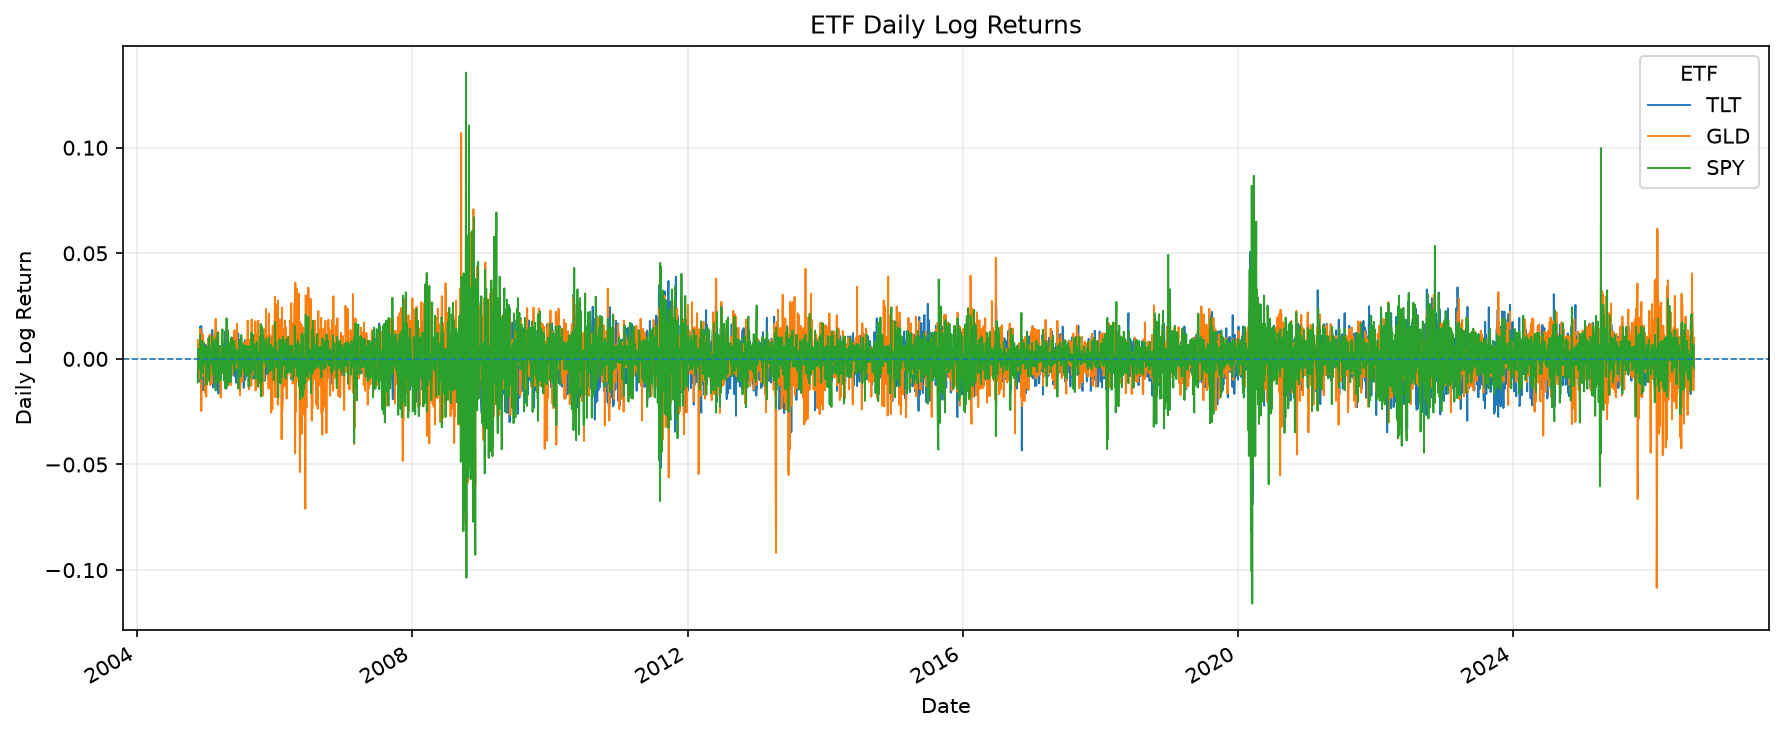

In [5]:
with TemporaryDirectory() as temporary_directory:
    etf_plot_path = Path(temporary_directory) / "step1_etf_log_returns.png"
    plot_etf_log_returns(data, etf_plot_path)
    display(Image(filename=str(etf_plot_path)))

### Required VIX-change figure

The plot shows the first difference of the VIX level. Positive observations indicate an increase in the index from the preceding common-sample row, while negative observations indicate a decrease. This sign interpretation follows directly from the Step 1 difference definition and is not a directional forecast for SPY.

**Source note.** Yahoo Finance VIX observations; project-team first-difference calculations and visualization. VIX financial interpretation follows Cboe Global Markets and Whaley (2009).

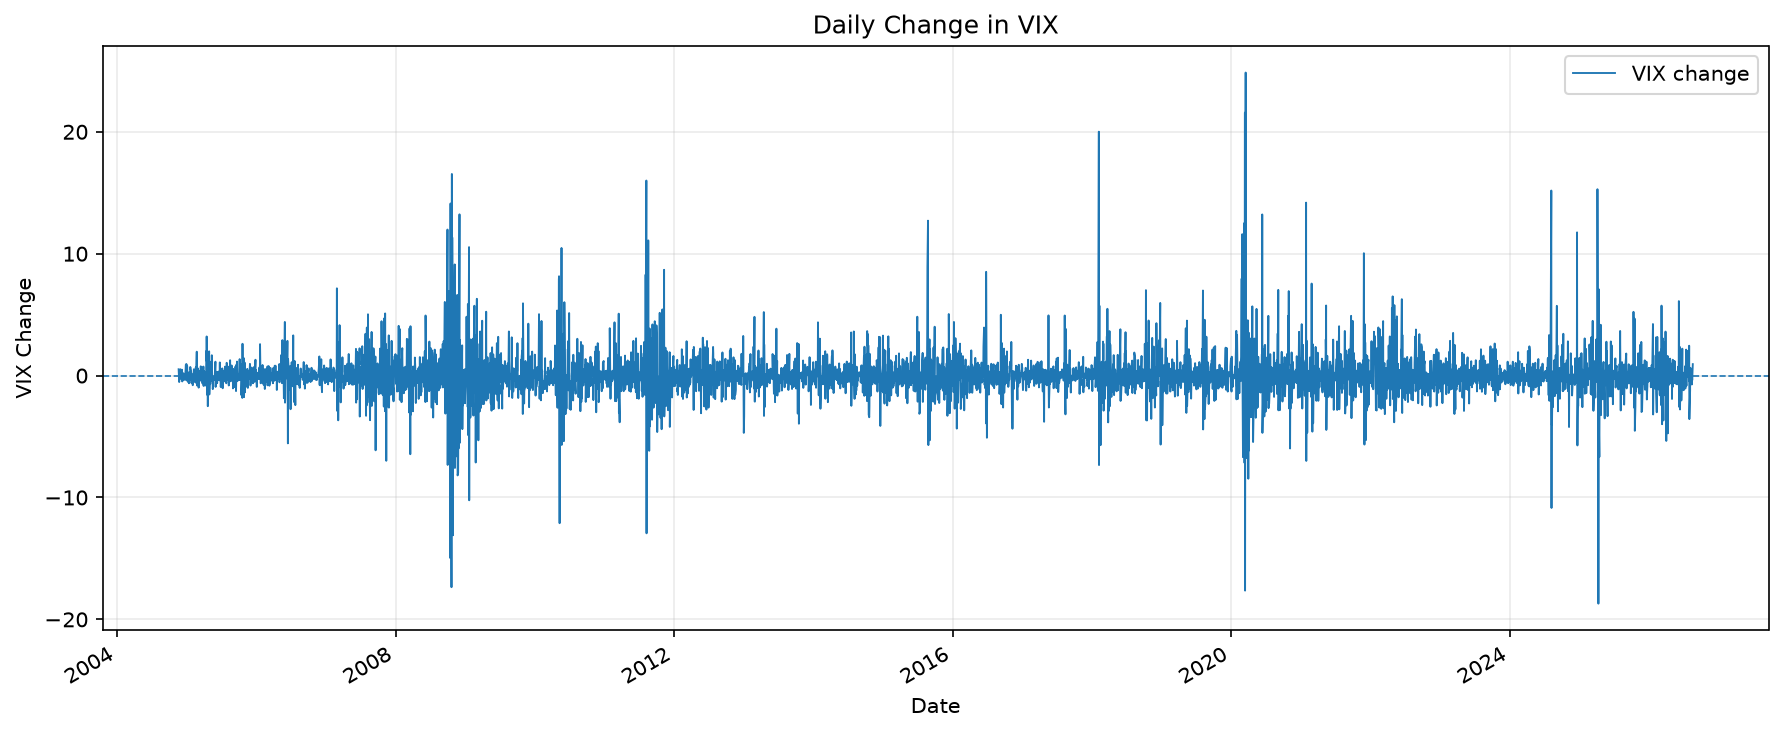

In [6]:
with TemporaryDirectory() as temporary_directory:
    vix_plot_path = Path(temporary_directory) / "step1_vix_change.png"
    plot_vix_change(data, vix_plot_path)
    display(Image(filename=str(vix_plot_path)))

### Interpretation, assumptions, and limitations

Step 1 is deliberately descriptive. The ETF panels reveal when daily log-return fluctuations cluster or spike, while the VIX-change panel reveals when option-implied volatility moves sharply between common-sample rows. The computed statistics above quantify the sample span, the largest observed absolute VIX movement, and the relative daily dispersion of the three ETF return series without introducing a regime model.

Key assumptions and limitations are: (1) the analysis uses the Yahoo Finance fields returned by the specified loader; (2) only the maximum **common** dates are retained, so observations missing for any one series are removed before lags; (3) there is no interpolation or forward fill; (4) `VIX_change` is an arithmetic first difference in VIX points, not a VIX return; (5) Step 1 contains no causal, predictive, or out-of-sample claim; and (6) later Step 2 regime models must treat this cleaned dataset as their canonical input rather than constructing a different sample.

## Step 2 - Modeling VIX Regimes: Discrete Markov Chains

Step 2 first treats the observed daily change in the VIX as a discretized state variable. The input is **only** the committed `VIX_change` series from Step 1; no live data are downloaded and no VIX-level thresholds are used. For each requested state count, the empirical distribution of daily VIX changes is divided by linear quantiles. Observations exactly equal to an interior cut are assigned to the higher-numbered state. This produces an observable finite-state Markov-chain representation whose transition probabilities are estimated from consecutive state counts. The general finite-state transition framework and likelihood treatment are standard Markov-chain constructions; Baum et al. provide a classical statistical treatment of probabilistic functions of Markov chains (Baum et al. 164-171).

<!-- citekey: baum1970maximization -->

**Greek letter used below:** π — *pi*, pronounced “pie”.

For states $i,j\in\{0,\ldots,K-1\}$, the estimated transition probability is

$$
P_{ij}=\Pr(S_{t+1}=j\mid S_t=i)=rac{N_{ij}}{\sum_j N_{ij}},
$$

with no pseudocount or smoothing. A stationary distribution satisfies

$$
\pi=\pi P,\qquad \sum_i\pi_i=1.
$$

The project estimates both $K=2$ and $K=3$. State numbers are ordered by increasingly positive `VIX_change`: State 0 contains the lower changes, while the highest-numbered state contains the larger positive changes. These labels describe **changes in implied volatility**, not low/high VIX levels themselves.

**Source note.** Market observations and `VIX_change`: Step 1 project data derived from Yahoo Finance. Markov-chain methodology: Baum et al. (1970). Quantile discretization, calculations, tables, and figure: project team.

### Markov candidate: K=2

**Quantile intervals**

,state,lower_bound,upper_bound
0,0,-inf,-0.099999
1,1,-0.099999,inf


**Transition matrix**

,state_0,state_1
from_state,,
0,0.479266,0.520734
1,0.518072,0.481928


...

**Transition matrix**

,state_0,state_1,state_2
from_state,,,
0,0.349311,0.300826,0.349862
1,0.233132,0.431706,0.335162
2,0.414020,0.268346,0.317634


**Stationary distribution**

,stationary_probability
state,
0,0.332174
1,0.333638
2,0.334187


,value
conditional_log_likelihood,-5913.883847
transition_observations,5464.000000
free_transition_parameters,6.000000


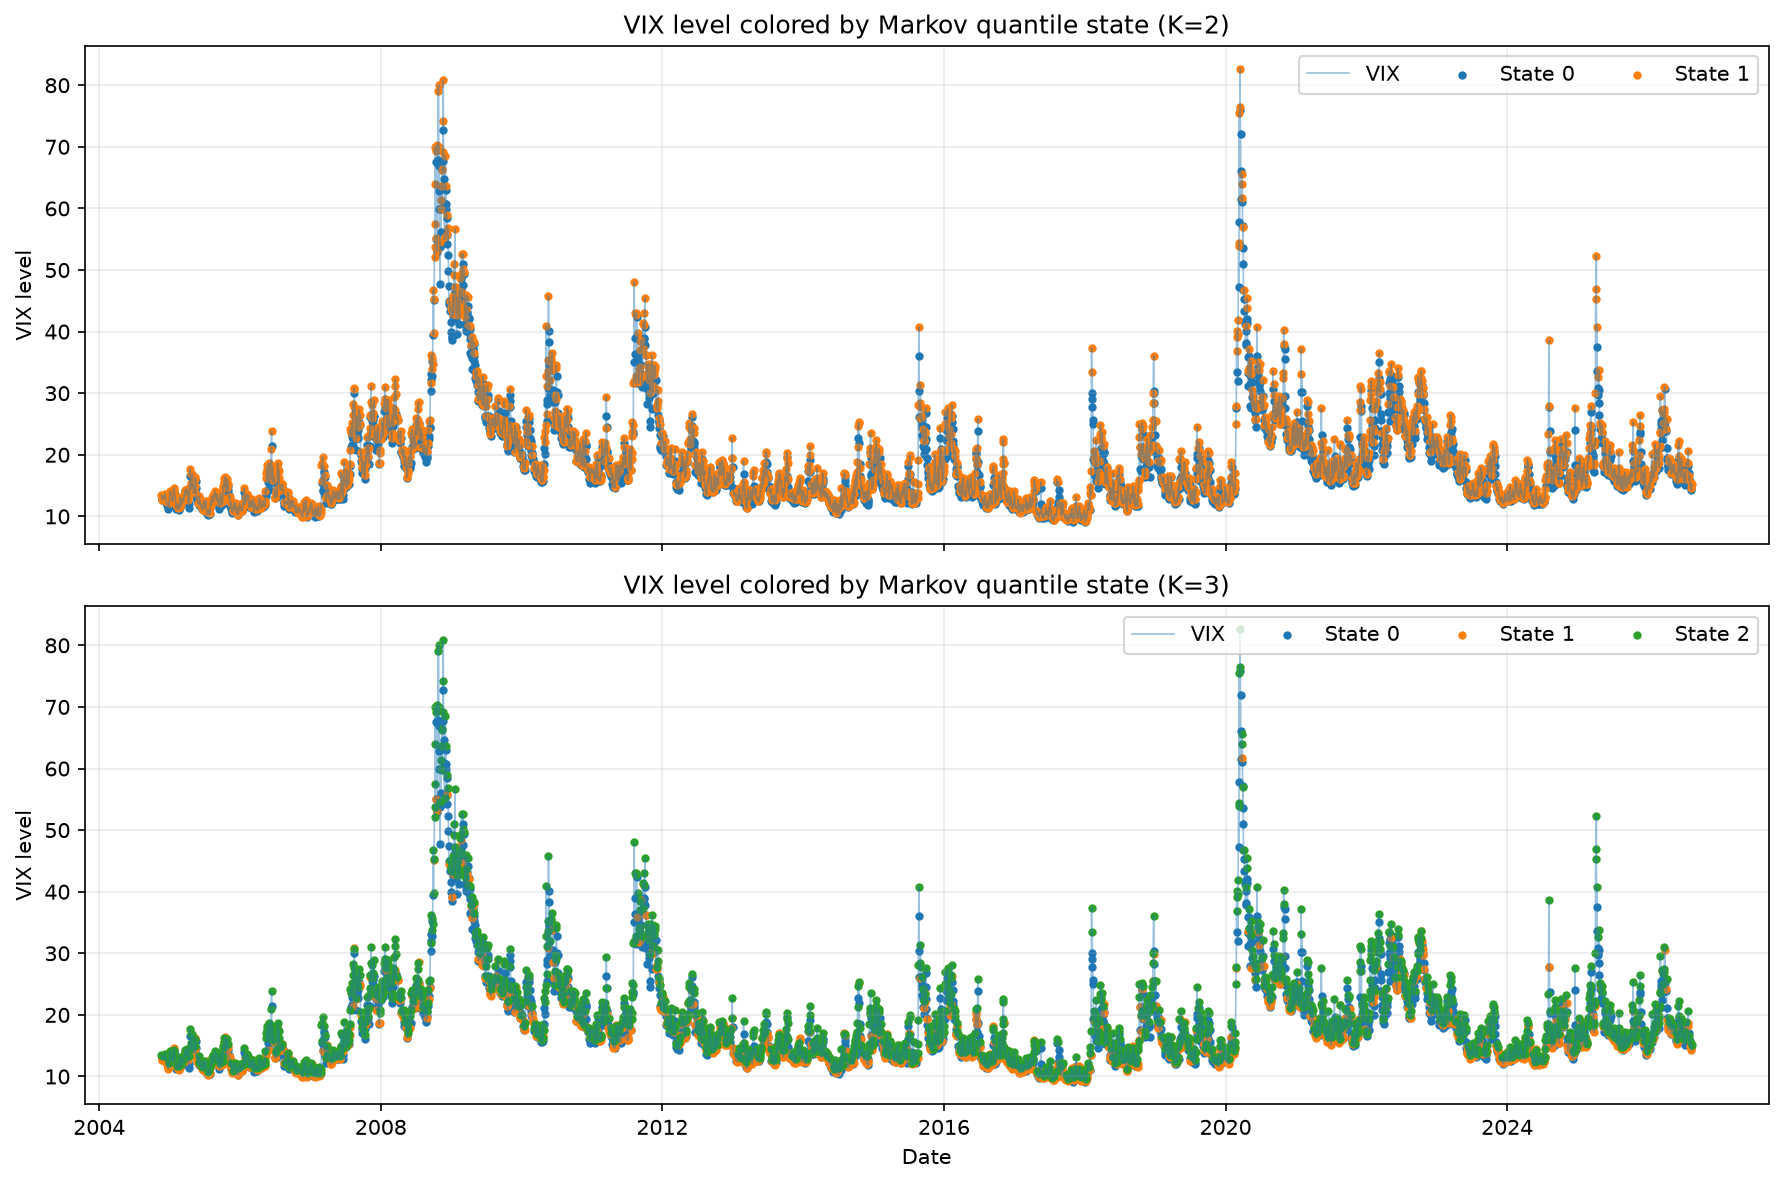

In [7]:
from vix_regime_allocation.markov_evaluation import evaluate_markov_candidate
from vix_regime_allocation.markov_plots import plot_markov_vix_states

markov_output_dir = repo_root / "reports/tables"
markov_figure_dir = repo_root / "reports/figures"
markov_output_dir.mkdir(parents=True, exist_ok=True)
markov_figure_dir.mkdir(parents=True, exist_ok=True)

markov_2 = evaluate_markov_candidate(data["VIX_change"], 2)
markov_3 = evaluate_markov_candidate(data["VIX_change"], 3)
markov_candidates = {2: markov_2, 3: markov_3}

for k, candidate in markov_candidates.items():
    candidate["thresholds"].to_csv(
        markov_output_dir / f"step2_markov_{k}_thresholds.csv", index=False
    )
    candidate["transition"].reset_index().to_csv(
        markov_output_dir / f"step2_markov_{k}_transition.csv", index=False
    )
    candidate["stationary"].reset_index().to_csv(
        markov_output_dir / f"step2_markov_{k}_stationary.csv", index=False
    )
    candidate["states"].rename_axis("Date").reset_index().to_csv(
        markov_output_dir / f"step2_markov_{k}_states.csv", index=False
    )

markov_figure_path = markov_figure_dir / "step2_markov_vix_states.png"
plot_markov_vix_states(
    data["VIX"], markov_2["states"], markov_3["states"], markov_figure_path
)

for k, candidate in markov_candidates.items():
    display(Markdown(f"### Markov candidate: K={k}"))
    display(Markdown("**Quantile intervals**"))
    display(candidate["thresholds"])
    display(Markdown("**Transition matrix**"))
    display(candidate["transition"])
    display(Markdown("**Stationary distribution**"))
    display(candidate["stationary"].to_frame())
    diagnostics = pd.Series(
        {
            "conditional_log_likelihood": candidate["log_likelihood"],
            "transition_observations": candidate["n_observations"],
            "free_transition_parameters": candidate["n_parameters"],
        },
        name="value",
    )
    display(diagnostics.to_frame())

assert markov_2["states"].index.equals(data.index)
assert markov_3["states"].index.equals(data.index)
Image(filename=str(markov_figure_path))

### Markov-state interpretation and limitations

The two-state specification separates below-median from at-or-above-median daily VIX changes; the three-state specification provides a lower, middle, and upper quantile partition. The transition matrices therefore answer a conditional-frequency question: given today's observed VIX-change state, how often did the next trading observation fall into each state in this sample? The stationary distributions summarize the long-run probabilities implied by the fitted transition matrices, provided the estimated chain has a unique stationary distribution.

The figure deliberately plots the **VIX level** while coloring observations by states inferred from **daily VIX changes**. A high VIX level can occur in a negative-change state when volatility is falling, and a low VIX level can occur in a positive-change state when volatility is rising. For that reason, the numerical labels are retained rather than assigning unsupported names such as “calm” or “crisis.”

This construction is descriptive and full-sample. Quantile thresholds are estimated from the full Step 1 sample, the Markov property is an imposed approximation, discretization discards within-state variation, and transition probabilities are assumed time-homogeneous over the sample. Step 3 will compare the two state counts within the Markov family rather than selecting one here.

**Source note.** Interpretation of the fitted sample objects and limitations: project team; finite-state Markov methodology: Baum et al. (1970).

<!-- citekey: baum1970maximization -->

## Works Cited

The following MLA 9 entries are rendered programmatically from the cited keys in the canonical `reports/references.bib` registry.

In [8]:
def _parse_bibtex_registry(text: str) -> dict[str, dict[str, str]]:
    entries: dict[str, dict[str, str]] = {}
    for match in re.finditer(r"@(\w+)\{([^,]+),\s*(.*?)\n\}", text, flags=re.DOTALL):
        entry_type, key, body = match.groups()
        fields = {
            field: value
            for field, value in re.findall(r'(\w+)\s*=\s*"([^"]*)"', body)
        }
        fields["entry_type"] = entry_type.lower()
        entries[key] = fields
    return entries


def _mla_author(author: str) -> str:
    authors = author.split(" and ")
    return authors[0] + (", et al." if len(authors) > 2 else "")


def _mla_entry(entry: dict[str, str]) -> str:
    author = _mla_author(entry["author"])
    if entry["entry_type"] == "article":
        pages = entry["pages"].replace("--", "-")
        return (
            f'{author} "{entry["title"]}." *{entry["journal"]}*, '
            f'vol. {entry["volume"]}, no. {entry["number"]}, {entry["year"]}, '
            f'pp. {pages}. doi:{entry["doi"]}.'
        )
    return (
        f'{author}. "{entry["title"]}." *{entry["publisher"]}*, '
        f'{entry["year"]}, {entry["url"]}. Accessed 19 Aug. 2026.'
    )


references = _parse_bibtex_registry(references_path.read_text(encoding="utf-8"))
cited_keys = ["whaley2009vix", "cboe2019vixfaq", "baum1970maximization"]
missing_keys = [key for key in cited_keys if key not in references]
assert not missing_keys, f"Unresolved citation keys: {missing_keys}"
display(Markdown(chr(10).join(f"- {_mla_entry(references[key])}" for key in cited_keys)))

- Whaley, Robert E. "Understanding the VIX." *The Journal of Portfolio Management*, vol. 35, no. 3, 2009, pp. 98-105. doi:10.3905/JPM.2009.35.3.098.
- Cboe Global Markets. "Cboe VIX FAQ." *Cboe Global Markets*, 2019, https://www.cboe.com/tradable_products/vix/faqs. Accessed 19 Aug. 2026.
- Baum, Leonard E., et al. "A Maximization Technique Occurring in the Statistical Analysis of Probabilistic Functions of Markov Chains." *The Annals of Mathematical Statistics*, vol. 41, no. 1, 1970, pp. 164-171. doi:10.1214/aoms/1177697196.